# Options Strategy Recommendation and Optimisation System
## Notebook 4 - Option Strategy Payoff Engine

This notebook converts Notebook 3's ranked strategy families into valid, tradeable option-leg combinations using Notebook 2's contract features. It calculates deterministic expiration payoffs and Monte Carlo estimates for probability of profit and expected profit.

Supported strategies: **Bull Call Spread, Bull Put Spread, Bear Put Spread, Bear Call Spread, Long Call, and Long Put**.

## Scope and modelling assumptions

- All legs in a strategy use the same expiry and a standard multiplier of 100 shares.
- Long legs enter at the ask; short legs enter at the bid. This is more conservative than using mid-prices.
- Payoffs are evaluated at expiry and exclude commissions, assignment costs, early exercise and volatility changes before expiry.
- Monte Carlo terminal prices follow geometric Brownian motion. Drift comes from observed 20-day momentum, annualised and capped between -25% and +25%; the user's outlook does not manufacture the expected return.
- This notebook creates and evaluates candidates. Notebook 5 performs genetic-algorithm optimisation.

## 1. Environment setup

If required, install packages once with: `pip install pandas numpy matplotlib`.

In [5]:
from __future__ import annotations

import json
import math
import re
import sys
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"Python: {sys.version.split()[0]} | pandas: {pd.__version__}")

Python: 3.9.23 | pandas: 2.3.2


## 2. Configuration and upstream inputs

Use the same ticker and bullish/bearish outlook as Notebooks 1-3.

In [7]:
TICKER = "CRM"
OUTLOOK = "bullish"  # allowed: bullish, bearish


In [8]:
NOTEBOOK2_ROOT = Path("outputs/notebook_02")
NOTEBOOK3_ROOT = Path("outputs/notebook_03")
NOTEBOOK4_ROOT = Path("outputs/notebook_04")
CONTRACT_MULTIPLIER = 100
MAX_CONTRACTS_PER_TYPE = 30
MAX_CANDIDATES_PER_STRATEGY = 500
MONTE_CARLO_PATHS = 20_000
RANDOM_SEED = 42
PAYOFF_GRID_POINTS = 401
PAYOFF_PROFILE_TOP_N = 10

def validate_settings(ticker: str, outlook: str) -> tuple[str, str]:
    ticker = ticker.strip().upper().replace(".", "-")
    outlook = outlook.strip().lower()
    if not ticker or not re.fullmatch(r"[A-Z0-9^=-]{1,15}", ticker):
        raise ValueError("Ticker is empty or contains unsupported characters.")
    if outlook not in {"bullish", "bearish"}:
        raise ValueError("OUTLOOK must be either 'bullish' or 'bearish'.")
    return ticker, outlook

ticker, outlook = validate_settings(TICKER, OUTLOOK)
run_name = f"{ticker}_{outlook}"
NOTEBOOK2_DIR = NOTEBOOK2_ROOT / ticker
NOTEBOOK3_DIR = NOTEBOOK3_ROOT / ticker / outlook
OUTPUT_DIR = NOTEBOOK4_ROOT / ticker / outlook
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
input_paths = {
    "feature_snapshot": NOTEBOOK2_DIR / "feature_snapshot.json",
    "option_features": NOTEBOOK2_DIR / "option_features.csv",
    "expiry_features": NOTEBOOK2_DIR / "expiry_features.csv",
    "ranked_strategies": NOTEBOOK3_DIR / "ranked_strategy_families.csv",
}
input_paths


{'feature_snapshot': WindowsPath('outputs/notebook_02/CRM/feature_snapshot.json'),
 'option_features': WindowsPath('outputs/notebook_02/CRM/option_features.csv'),
 'expiry_features': WindowsPath('outputs/notebook_02/CRM/expiry_features.csv'),
 'ranked_strategies': WindowsPath('outputs/notebook_03/CRM/bullish/ranked_strategy_families.csv')}

In [9]:
missing_files = [str(path) for path in input_paths.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Required upstream outputs were not found. Run Notebooks 1-3 with the same ticker/outlook first. Missing: "
        + ", ".join(missing_files)
    )

with input_paths["feature_snapshot"].open("r", encoding="utf-8") as file:
    feature_snapshot = json.load(file)
option_features = pd.read_csv(input_paths["option_features"])
expiry_features = pd.read_csv(input_paths["expiry_features"])
ranked_strategies = pd.read_csv(input_paths["ranked_strategies"])

if feature_snapshot.get("request") != {"ticker": ticker}:
    raise ValueError("Notebook 2 snapshot does not match the configured ticker.")
if option_features.empty or expiry_features.empty or ranked_strategies.empty:
    raise ValueError("At least one upstream dataset is empty.")

recommended = ranked_strategies.loc[ranked_strategies["recommended_for_next_stage"].astype(str).str.lower().eq("true")].copy()
if recommended.empty:
    raise ValueError("Notebook 3 did not mark any strategy for the payoff stage.")

print(f"Loaded {len(option_features):,} contracts and {len(recommended):,} recommended strategy families.")
display(recommended[["rank", "strategy_id", "name", "selected_expiry", "reasoning_score"]])

Loaded 125 contracts and 3 recommended strategy families.


,rank,strategy_id,name,selected_expiry,reasoning_score
0,1,bull_call_spread,Bull Call Spread,2026-10-02,105.0000
1,2,long_call,Long Call,2026-10-02,95.0000
2,3,bull_put_spread,Bull Put Spread,2026-10-02,65.0000


## 3. Prepare the contract universe and chromosome indices

Notebook 5 uses the chromosome `[strategy_type, expiry_index, long_strike_index, short_strike_index]`. A short-strike index of `-1` identifies a one-leg strategy.

In [11]:
numeric_columns = [
    "dte", "strike", "spot_price", "mid_price", "bid", "ask",
    "impliedVolatility", "liquidity_score", "delta", "gamma", "theta_day", "vega_1pct"
]
for column in numeric_columns:
    if column in option_features.columns:
        option_features[column] = pd.to_numeric(option_features[column], errors="coerce")
option_features["expiry"] = pd.to_datetime(option_features["expiry"]).dt.strftime("%Y-%m-%d")
option_features["candidate_quality_pass"] = option_features["candidate_quality_pass"].astype(str).str.lower().eq("true")
option_features = option_features.loc[option_features["candidate_quality_pass"]].copy()
option_features["long_entry_price"] = np.where(option_features["ask"].gt(0), option_features["ask"], option_features["mid_price"])
option_features["short_entry_price"] = np.where(option_features["bid"].gt(0), option_features["bid"], option_features["mid_price"])

expiry_order = {expiry: index for index, expiry in enumerate(sorted(expiry_features["expiry"].astype(str).unique()))}
strategy_order = {strategy_id: index for index, strategy_id in enumerate(ranked_strategies.sort_values("rank")["strategy_id"].unique())}
option_features = option_features.sort_values(["expiry", "option_type", "strike", "liquidity_score"], ascending=[True, True, True, False])
option_features = option_features.drop_duplicates(["expiry", "option_type", "strike"], keep="first")
option_features["strike_index"] = option_features.groupby(["expiry", "option_type"]).cumcount()
option_features["expiry_index"] = option_features["expiry"].map(expiry_order)

spot_price = float(option_features["spot_price"].median())
underlying_features = feature_snapshot["underlying_features"]
momentum_20 = underlying_features.get("momentum_20")
momentum_20 = float(momentum_20) if momentum_20 is not None and np.isfinite(float(momentum_20)) else 0.0
annual_drift = float(np.clip(math.log1p(max(momentum_20, -0.95)) * (252 / 20), -0.25, 0.25))
print(f"Spot: ${spot_price:,.2f} | observed annualised drift used for simulation: {annual_drift:.2%}")

Spot: $209.17 | observed annualised drift used for simulation: 25.00%


## 4. Payoff definitions and structural rules

Valid two-leg structures require:

- Bull Call Spread: long-call strike < short-call strike.
- Bull Put Spread: long-put strike < short-put strike.
- Bear Put Spread: short-put strike < long-put strike.
- Bear Call Spread: short-call strike < long-call strike.

In [13]:
STRATEGY_OPTION_TYPE = {
    "bull_call_spread": "call", "bull_put_spread": "put", "long_call": "call",
    "bear_put_spread": "put", "bear_call_spread": "call", "long_put": "put",
}
ONE_LEG_STRATEGIES = {"long_call", "long_put"}
DEBIT_SPREADS = {"bull_call_spread", "bear_put_spread"}
CREDIT_SPREADS = {"bull_put_spread", "bear_call_spread"}

def intrinsic_value(stock_prices: np.ndarray, strike: float, option_type: str) -> np.ndarray:
    return np.maximum(stock_prices - strike, 0) if option_type == "call" else np.maximum(strike - stock_prices, 0)

def candidate_payoff(stock_prices: np.ndarray, candidate: dict[str, Any] | pd.Series) -> np.ndarray:
    option_type = candidate["option_type"]
    payoff = intrinsic_value(stock_prices, float(candidate["long_strike"]), option_type)
    if int(candidate["short_strike_index"]) >= 0:
        payoff -= intrinsic_value(stock_prices, float(candidate["short_strike"]), option_type)
    payoff += float(candidate["entry_cashflow_per_share"])
    return payoff

def structural_order_is_valid(strategy_id: str, long_strike: float, short_strike: float | None) -> bool:
    if strategy_id in ONE_LEG_STRATEGIES:
        return short_strike is None
    if short_strike is None:
        return False
    if strategy_id in {"bull_call_spread", "bull_put_spread"}:
        return long_strike < short_strike
    if strategy_id in {"bear_put_spread", "bear_call_spread"}:
        return short_strike < long_strike
    return False

def analytical_metrics(strategy_id: str, long_strike: float, short_strike: float | None, premium: float) -> dict[str, float]:
    if strategy_id == "long_call":
        return {"max_profit": np.inf, "max_loss": premium * CONTRACT_MULTIPLIER, "breakeven": long_strike + premium}
    if strategy_id == "long_put":
        return {"max_profit": max(0, long_strike - premium) * CONTRACT_MULTIPLIER, "max_loss": premium * CONTRACT_MULTIPLIER, "breakeven": long_strike - premium}
    width = abs(float(short_strike) - long_strike)
    if strategy_id == "bull_call_spread":
        return {"max_profit": (width - premium) * CONTRACT_MULTIPLIER, "max_loss": premium * CONTRACT_MULTIPLIER, "breakeven": long_strike + premium}
    if strategy_id == "bear_put_spread":
        return {"max_profit": (width - premium) * CONTRACT_MULTIPLIER, "max_loss": premium * CONTRACT_MULTIPLIER, "breakeven": long_strike - premium}
    if strategy_id == "bull_put_spread":
        return {"max_profit": premium * CONTRACT_MULTIPLIER, "max_loss": (width - premium) * CONTRACT_MULTIPLIER, "breakeven": float(short_strike) - premium}
    if strategy_id == "bear_call_spread":
        return {"max_profit": premium * CONTRACT_MULTIPLIER, "max_loss": (width - premium) * CONTRACT_MULTIPLIER, "breakeven": float(short_strike) + premium}
    raise ValueError(f"Unsupported strategy: {strategy_id}")

def finite_or_none(value: Any) -> float | None:
    try:
        value = float(value)
        return value if math.isfinite(value) else None
    except (TypeError, ValueError):
        return None


## 5. Generate valid exact-leg candidates

In [15]:
def leg_value(leg: pd.Series, column: str, default: float = 0.0) -> float:
    value = leg.get(column, default)
    return float(value) if pd.notna(value) else default

def build_candidate(strategy_row: pd.Series, long_leg: pd.Series, short_leg: pd.Series | None) -> tuple[dict[str, Any] | None, str | None]:
    strategy_id = strategy_row["strategy_id"]
    long_strike = float(long_leg["strike"])
    short_strike = None if short_leg is None else float(short_leg["strike"])
    if not structural_order_is_valid(strategy_id, long_strike, short_strike):
        return None, "invalid_strike_order"

    long_price = float(long_leg["long_entry_price"])
    short_price = 0.0 if short_leg is None else float(short_leg["short_entry_price"])
    entry_cashflow = -long_price + short_price
    premium = abs(entry_cashflow)
    expected_entry_type = "debit" if strategy_id in ONE_LEG_STRATEGIES | DEBIT_SPREADS else "credit"
    actual_entry_type = "credit" if entry_cashflow > 0 else "debit"
    if premium <= 0 or actual_entry_type != expected_entry_type:
        return None, "invalid_net_premium"

    if short_leg is not None:
        width = abs(short_strike - long_strike)
        if premium >= width:
            return None, "premium_not_below_width"

    metrics = analytical_metrics(strategy_id, long_strike, short_strike, premium)
    if metrics["max_loss"] <= 0 or (math.isfinite(metrics["max_profit"]) and metrics["max_profit"] <= 0):
        return None, "non_positive_payoff_metric"

    short_index = -1 if short_leg is None else int(short_leg["strike_index"])
    candidate_id = f"{strategy_id}|{long_leg['expiry']}|L{int(long_leg['strike_index'])}|S{short_index}"
    liquidity_score = leg_value(long_leg, "liquidity_score") if short_leg is None else min(leg_value(long_leg, "liquidity_score"), leg_value(short_leg, "liquidity_score"))
    net_delta = leg_value(long_leg, "delta") - (0 if short_leg is None else leg_value(short_leg, "delta"))
    net_gamma = leg_value(long_leg, "gamma") - (0 if short_leg is None else leg_value(short_leg, "gamma"))
    net_theta = leg_value(long_leg, "theta_day") - (0 if short_leg is None else leg_value(short_leg, "theta_day"))
    net_vega = leg_value(long_leg, "vega_1pct") - (0 if short_leg is None else leg_value(short_leg, "vega_1pct"))
    max_profit = metrics["max_profit"]
    reward_to_risk = max_profit / metrics["max_loss"] if math.isfinite(max_profit) else np.nan

    candidate = {
        "candidate_id": candidate_id, "strategy_type": strategy_id, "strategy_name": strategy_row["name"],
        "strategy_rank": int(strategy_row["rank"]), "reasoning_score": float(strategy_row["reasoning_score"]),
        "expiry": long_leg["expiry"], "dte": int(long_leg["dte"]), "option_type": long_leg["option_type"],
        "strategy_index": strategy_order[strategy_id], "expiry_index": int(long_leg["expiry_index"]),
        "long_strike_index": int(long_leg["strike_index"]), "short_strike_index": short_index,
        "long_symbol": long_leg["contractSymbol"], "long_strike": long_strike, "long_entry_price": long_price,
        "short_symbol": None if short_leg is None else short_leg["contractSymbol"],
        "short_strike": np.nan if short_leg is None else short_strike, "short_entry_price": short_price,
        "entry_type": actual_entry_type, "net_premium_per_share": premium, "entry_cashflow_per_share": entry_cashflow,
        "max_profit": max_profit, "max_loss": metrics["max_loss"], "breakeven": metrics["breakeven"],
        "reward_to_risk": reward_to_risk, "liquidity_score": liquidity_score,
        "net_delta": net_delta, "net_gamma": net_gamma, "net_theta_day": net_theta, "net_vega_1pct": net_vega,
    }
    candidate["chromosome"] = str([candidate["strategy_index"], candidate["expiry_index"], candidate["long_strike_index"], candidate["short_strike_index"]])
    return candidate, None

def select_contract_pool(expiry: str, option_type: str) -> pd.DataFrame:
    pool = option_features.loc[(option_features["expiry"] == expiry) & (option_features["option_type"] == option_type)].copy()
    if len(pool) > MAX_CONTRACTS_PER_TYPE:
        pool = pool.nlargest(MAX_CONTRACTS_PER_TYPE, "liquidity_score")
    return pool.sort_values("strike").reset_index(drop=True)


In [16]:
candidate_rows: list[dict[str, Any]] = []
rejections: list[dict[str, str]] = []

for _, strategy_row in recommended.sort_values("rank").iterrows():
    strategy_id = strategy_row["strategy_id"]
    expiry = pd.Timestamp(strategy_row["selected_expiry"]).strftime("%Y-%m-%d")
    option_type = STRATEGY_OPTION_TYPE[strategy_id]
    pool = select_contract_pool(expiry, option_type)
    strategy_candidates: list[dict[str, Any]] = []

    if strategy_id in ONE_LEG_STRATEGIES:
        for _, long_leg in pool.iterrows():
            candidate, reason = build_candidate(strategy_row, long_leg, None)
            if candidate is not None:
                strategy_candidates.append(candidate)
            else:
                rejections.append({"strategy_type": strategy_id, "reason": str(reason)})
    else:
        for _, first_leg in pool.iterrows():
            for _, second_leg in pool.iterrows():
                if int(first_leg["strike_index"]) == int(second_leg["strike_index"]):
                    continue
                long_leg, short_leg = first_leg, second_leg
                candidate, reason = build_candidate(strategy_row, long_leg, short_leg)
                if candidate is not None:
                    strategy_candidates.append(candidate)
                elif reason != "invalid_strike_order":
                    rejections.append({"strategy_type": strategy_id, "reason": str(reason)})

    if strategy_candidates:
        strategy_frame = pd.DataFrame(strategy_candidates).drop_duplicates("candidate_id")
        strategy_frame["preliminary_quality"] = strategy_frame["liquidity_score"] + strategy_frame["reasoning_score"]
        strategy_frame = strategy_frame.nlargest(MAX_CANDIDATES_PER_STRATEGY, "preliminary_quality")
        candidate_rows.extend(strategy_frame.drop(columns="preliminary_quality").to_dict(orient="records"))

candidate_table = pd.DataFrame(candidate_rows).drop_duplicates("candidate_id").reset_index(drop=True)
if candidate_table.empty:
    raise ValueError("No valid exact-leg candidates were generated from the recommended strategies.")
print(f"Generated {len(candidate_table):,} valid candidates.")
display(candidate_table.groupby(["strategy_type", "strategy_name"], as_index=False).agg(candidates=("candidate_id", "count"), median_liquidity=("liquidity_score", "median")))

Generated 64 valid candidates.


,strategy_type,strategy_name,candidates,median_liquidity
0,bull_call_spread,Bull Call Spread,21,43.4615
1,bull_put_spread,Bull Put Spread,36,44.8684
2,long_call,Long Call,7,44.8077


## 6. Monte Carlo probability of profit and expected value

For each expiry, terminal prices are simulated once and reused across candidates. This provides a fair comparison under the same scenarios. Implied volatility determines dispersion; observed momentum determines capped drift.

In [18]:
rng = np.random.default_rng(RANDOM_SEED)
simulation_cache: dict[str, np.ndarray] = {}
expiry_lookup = expiry_features.assign(expiry=pd.to_datetime(expiry_features["expiry"]).dt.strftime("%Y-%m-%d")).set_index("expiry")

for expiry in candidate_table["expiry"].unique():
    expiry_row = expiry_lookup.loc[expiry]
    ttm = max(float(expiry_row["dte"]) / 365, 1 / 365)
    volatility = float(expiry_row["atm_implied_volatility"])
    shocks = rng.standard_normal(MONTE_CARLO_PATHS)
    simulation_cache[expiry] = spot_price * np.exp((annual_drift - 0.5 * volatility**2) * ttm + volatility * math.sqrt(ttm) * shocks)

simulation_metrics: list[dict[str, float]] = []
for _, candidate in candidate_table.iterrows():
    terminal_prices = simulation_cache[candidate["expiry"]]
    pnl = candidate_payoff(terminal_prices, candidate) * CONTRACT_MULTIPLIER
    expected_profit = float(np.mean(pnl))
    max_loss = float(candidate["max_loss"])
    simulation_metrics.append({
        "probability_of_profit": float(np.mean(pnl > 0)),
        "expected_profit": expected_profit,
        "expected_return_on_risk": expected_profit / max_loss,
        "median_profit": float(np.median(pnl)),
        "p05_profit": float(np.quantile(pnl, 0.05)),
        "p95_profit": float(np.quantile(pnl, 0.95)),
    })
candidate_table = pd.concat([candidate_table, pd.DataFrame(simulation_metrics)], axis=1)
candidate_table["payoff_engine_rank"] = candidate_table.groupby("strategy_type")["expected_return_on_risk"].rank(method="first", ascending=False).astype(int)
candidate_table = candidate_table.sort_values(["strategy_rank", "payoff_engine_rank"]).reset_index(drop=True)
display(candidate_table[["strategy_name", "long_strike", "short_strike", "entry_type", "net_premium_per_share", "max_profit", "max_loss", "breakeven", "probability_of_profit", "expected_profit", "expected_return_on_risk"]].head(15))

,strategy_name,long_strike,short_strike,entry_type,net_premium_per_share,max_profit,max_loss,breakeven,probability_of_profit,expected_profit,expected_return_on_risk
0,Bull Call Spread,215.0000,220.0000,debit,2.3000,270.0000,230.0000,217.3000,0.0129,-193.6145,-0.8418
1,Bull Call Spread,215.0000,225.0000,debit,4.2000,580.0000,420.0000,219.2000,0.0001,-383.6145,-0.9134
2,Bull Call Spread,215.0000,230.0000,debit,5.8000,920.0000,580.0000,220.8000,0.0000,-543.6145,-0.9373
3,Bull Call Spread,215.0000,235.0000,debit,6.6800,"1,332.0000",668.0000,221.6800,0.0000,-631.6145,-0.9455
4,Bull Call Spread,215.0000,240.0000,debit,7.4000,"1,760.0000",740.0000,222.4000,0.0000,-703.6145,-0.9508
5,Bull Call Spread,215.0000,250.0000,debit,8.6600,"2,634.0000",866.0000,223.6600,0.0000,-829.6145,-0.9580
6,Bull Call Spread,230.0000,240.0000,debit,1.6000,840.0000,160.0000,231.6000,0.0000,-160.0000,-1.0000
7,Bull Call Spread,230.0000,235.0000,debit,0.8800,412.0000,88.0000,230.8800,0.0000,-88.0000,-1.0000
8,Bull Call Spread,220.0000,250.0000,debit,6.3600,"2,364.0000",636.0000,226.3600,0.0000,-636.0000,-1.0000
9,Bull Call Spread,220.0000,225.0000,debit,1.9000,310.0000,190.0000,221.9000,0.0000,-190.0000,-1.0000


## 7. Payoff curves across terminal stock prices

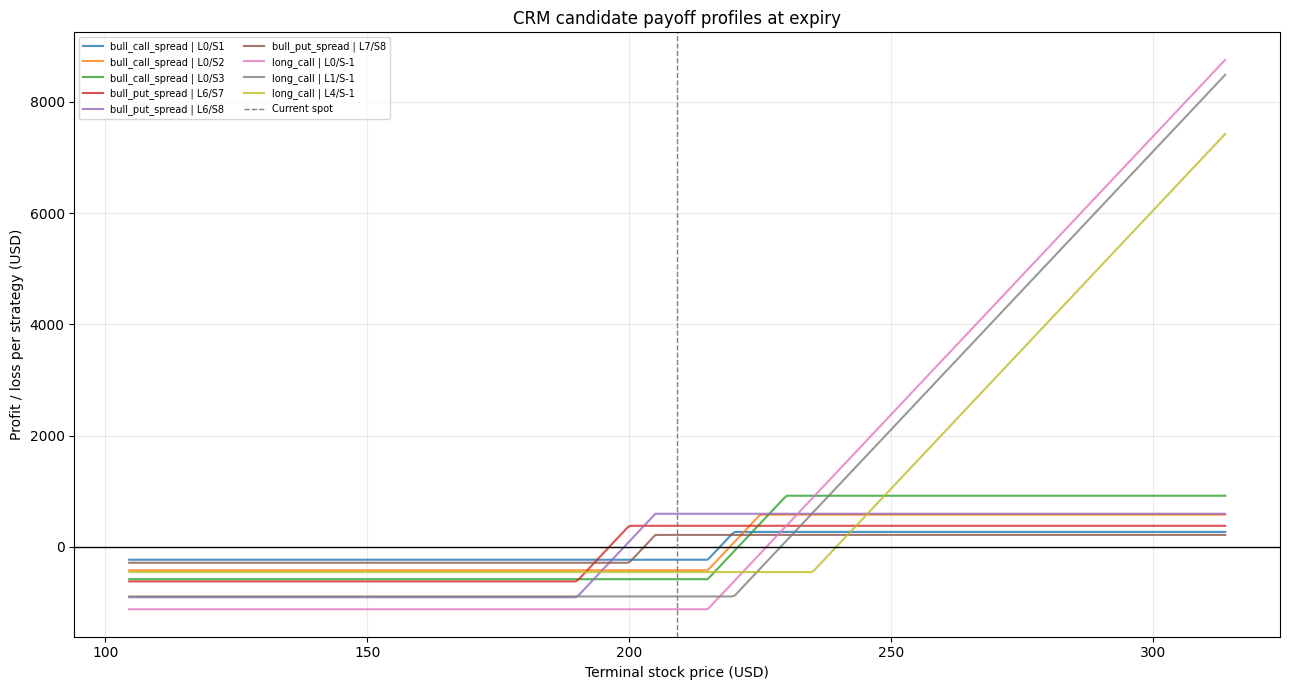

In [20]:
grid_low = max(0.01, min(spot_price * 0.50, float(expiry_features["expected_lower_price"].min()) * 0.85))
grid_high = max(spot_price * 1.50, float(expiry_features["expected_upper_price"].max()) * 1.15)
stock_price_grid = np.linspace(grid_low, grid_high, PAYOFF_GRID_POINTS)
profile_candidates = candidate_table.sort_values(["strategy_rank", "payoff_engine_rank"]).groupby("strategy_type", as_index=False).head(max(1, PAYOFF_PROFILE_TOP_N // len(recommended)))
profile_rows: list[pd.DataFrame] = []
for _, candidate in profile_candidates.iterrows():
    pnl = candidate_payoff(stock_price_grid, candidate) * CONTRACT_MULTIPLIER
    profile_rows.append(pd.DataFrame({
        "candidate_id": candidate["candidate_id"],
        "strategy_type": candidate["strategy_type"],
        "terminal_stock_price": stock_price_grid,
        "profit_loss": pnl,
    }))
payoff_profiles = pd.concat(profile_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(13, 7))
for candidate_id, group in payoff_profiles.groupby("candidate_id"):
    label = group["strategy_type"].iloc[0] + " | " + candidate_id.split("|")[-2] + "/" + candidate_id.split("|")[-1]
    ax.plot(group["terminal_stock_price"], group["profit_loss"], label=label, alpha=0.80)
ax.axhline(0, color="black", linewidth=1)
ax.axvline(spot_price, color="grey", linestyle="--", linewidth=1, label="Current spot")
ax.set_title(f"{ticker} candidate payoff profiles at expiry")
ax.set_xlabel("Terminal stock price (USD)")
ax.set_ylabel("Profit / loss per strategy (USD)")
ax.grid(alpha=0.25)
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 8. Payoff-engine quality checks

In [22]:
def row_structure_valid(row: pd.Series) -> bool:
    short_strike = None if int(row["short_strike_index"]) < 0 else float(row["short_strike"])
    return structural_order_is_valid(row["strategy_type"], float(row["long_strike"]), short_strike)

quality_checks = {
    "candidate_table_is_not_empty": not candidate_table.empty,
    "all_candidate_ids_are_unique": not candidate_table["candidate_id"].duplicated().any(),
    "all_strike_structures_are_valid": bool(candidate_table.apply(row_structure_valid, axis=1).all()),
    "all_net_premiums_are_positive": bool(candidate_table["net_premium_per_share"].gt(0).all()),
    "all_maximum_losses_are_positive": bool(candidate_table["max_loss"].gt(0).all()),
    "all_probabilities_are_bounded": bool(candidate_table["probability_of_profit"].between(0, 1).all()),
    "all_expected_profits_are_finite": bool(np.isfinite(candidate_table["expected_profit"]).all()),
    "all_chromosome_fields_exist": bool(candidate_table[["strategy_index", "expiry_index", "long_strike_index", "short_strike_index"]].notna().all().all()),
    "every_recommended_strategy_has_candidates": set(recommended["strategy_id"]) == set(candidate_table["strategy_type"]),
    "payoff_profiles_cover_selected_candidates": set(profile_candidates["candidate_id"]) == set(payoff_profiles["candidate_id"]),
}
payoff_quality_report = pd.DataFrame([{"check": name, "passed": bool(passed)} for name, passed in quality_checks.items()])
display(payoff_quality_report)
failed = payoff_quality_report.loc[~payoff_quality_report["passed"], "check"].tolist()
if failed:
    raise AssertionError(f"Payoff-engine quality checks failed: {failed}")
print("All payoff-engine quality checks passed.")

,check,passed
0,candidate_table_is_not_empty,True
1,all_candidate_ids_are_unique,True
2,all_strike_structures_are_valid,True
3,all_net_premiums_are_positive,True
4,all_maximum_losses_are_positive,True
5,all_probabilities_are_bounded,True
6,all_expected_profits_are_finite,True
7,all_chromosome_fields_exist,True
8,every_recommended_strategy_has_candidates,True
9,payoff_profiles_cover_selected_candidates,True


All payoff-engine quality checks passed.


## 9. Export the Notebook 5 candidate universe

In [24]:
rejection_summary = Counter(item["reason"] for item in rejections)
engine_snapshot = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "request": {"ticker": ticker, "outlook": outlook},
    "spot_price": spot_price,
    "annual_drift_from_momentum": annual_drift,
    "monte_carlo_paths": MONTE_CARLO_PATHS,
    "random_seed": RANDOM_SEED,
    "candidate_count": int(len(candidate_table)),
    "candidate_count_by_strategy": candidate_table["strategy_type"].value_counts().to_dict(),
    "rejection_summary": dict(rejection_summary),
    "chromosome_schema": ["strategy_type", "expiry_index", "long_strike_index", "short_strike_index"],
    "execution_price_assumption": {"long_leg": "ask", "short_leg": "bid"},
}

export_paths = {
    "candidate_universe": OUTPUT_DIR / "candidate_universe.csv",
    "payoff_profiles": OUTPUT_DIR / "payoff_profiles.csv",
    "monte_carlo_summary": OUTPUT_DIR / "monte_carlo_summary.csv",
    "generation_trace": OUTPUT_DIR / "generation_trace.json",
    "engine_snapshot": OUTPUT_DIR / "payoff_engine_snapshot.json",
    "quality_report": OUTPUT_DIR / "payoff_quality_report.csv",
}
candidate_table.to_csv(export_paths["candidate_universe"], index=False)
payoff_profiles.to_csv(export_paths["payoff_profiles"], index=False)
candidate_table[["candidate_id", "strategy_type", "probability_of_profit", "expected_profit", "expected_return_on_risk", "median_profit", "p05_profit", "p95_profit"]].to_csv(export_paths["monte_carlo_summary"], index=False)
payoff_quality_report.to_csv(export_paths["quality_report"], index=False)
with export_paths["generation_trace"].open("w", encoding="utf-8") as file:
    json.dump({"rejections": rejections, "rejection_summary": dict(rejection_summary)}, file, indent=2)
with export_paths["engine_snapshot"].open("w", encoding="utf-8") as file:
    json.dump(engine_snapshot, file, indent=2, allow_nan=False)

export_manifest = pd.DataFrame([{"dataset": name, "path": str(path), "exists": path.exists()} for name, path in export_paths.items()])
display(export_manifest)
success_marker = OUTPUT_DIR / "_SUCCESS.json"
success_marker.write_text(json.dumps({
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "request": {"ticker": ticker, "outlook": outlook},
    "notebook": "04_Option_Strategy_Payoff_Engine.ipynb",
}, indent=2), encoding="utf-8")
print(f"Completion marker: {success_marker}")


,dataset,path,exists
0,candidate_universe,outputs\notebook_04\CRM\bullish\candidate_universe.csv,True
1,payoff_profiles,outputs\notebook_04\CRM\bullish\payoff_profiles.csv,True
2,monte_carlo_summary,outputs\notebook_04\CRM\bullish\monte_carlo_summary.csv,True
3,generation_trace,outputs\notebook_04\CRM\bullish\generation_trace.json,True
4,engine_snapshot,outputs\notebook_04\CRM\bullish\payoff_engine_snapshot.json,True
5,quality_report,outputs\notebook_04\CRM\bullish\payoff_quality_report.csv,True


Completion marker: outputs\notebook_04\CRM\bullish\_SUCCESS.json


## 10. Key payoff fields

In [26]:
payoff_dictionary = pd.DataFrame([
    ("chromosome", "[strategy index, expiry index, long strike index, short strike index]"),
    ("entry_cashflow_per_share", "Negative for debit; positive for credit"),
    ("net_premium_per_share", "Absolute debit or credit using ask/bid execution prices"),
    ("max_profit / max_loss", "Expiration payoff limits per 100-share strategy"),
    ("breakeven", "Underlying price where expiration profit equals zero"),
    ("reward_to_risk", "Maximum profit divided by maximum loss; undefined for unlimited-profit long calls"),
    ("probability_of_profit", "Share of Monte Carlo expiry scenarios with positive profit"),
    ("expected_profit", "Mean Monte Carlo expiration profit per strategy"),
    ("expected_return_on_risk", "Expected profit divided by maximum loss"),
    ("p05_profit / p95_profit", "5th and 95th percentile simulated profit"),
], columns=["field", "meaning"])
display(payoff_dictionary)

,field,meaning
0,chromosome,"[strategy index, expiry index, long strike index, short strike index]"
1,entry_cashflow_per_share,Negative for debit; positive for credit
2,net_premium_per_share,Absolute debit or credit using ask/bid execution prices
3,max_profit / max_loss,Expiration payoff limits per 100-share strategy
4,breakeven,Underlying price where expiration profit equals zero
5,reward_to_risk,Maximum profit divided by maximum loss; undefined for unlimited-profit long calls
6,probability_of_profit,Share of Monte Carlo expiry scenarios with positive profit
7,expected_profit,Mean Monte Carlo expiration profit per strategy
8,expected_return_on_risk,Expected profit divided by maximum loss
9,p05_profit / p95_profit,5th and 95th percentile simulated profit


## Notebook 4 completion criteria

Notebook 4 is complete when all ten payoff-engine checks pass and six output files are created. Notebook 5 can then treat each valid row as a feasible chromosome and optimise expectancy, probability of profit, return on risk and liquidity without generating impossible strike combinations.